In [4]:
import pkg_resources
print(pkg_resources.__file__)
#Node2Vec just suport setuptool 80, so I had to downgrade it to that version

/Users/felipe/Documents/BSE/Term-2/Networks/PS2/.venv/lib/python3.12/site-packages/pkg_resources/__init__.py


In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from node2vec import Node2Vec
from sklearn.decomposition import PCA

## 4.1 
#### Here he perfomr the Erdos-Renyi Graph, using the pre-existing function, we plot it in the end of this subsection

#### Relationship between average degree and edge probability

In an Erdős–Rényi random graph $G(n,p)$, each pair of nodes is connected independently with probability $p$.

For a given node, there are $n-1$ possible neighbors. Since each possible edge appears with probability $p$, the **expected degree** of a node is:

$$
E[k] = (n-1)p
$$

If we want the network to have a target **average degree** $\langle k \rangle$, we set the expected degree equal to this value:

$$
\langle k \rangle = (n-1)p
$$

Solving for $p$, we obtain:

$$
p = \frac{\langle k \rangle}{n-1}
$$

Therefore, given $n$ and the desired average degree $\langle k \rangle$, we compute the probability $p$ using this formula before generating the Erdős–Rényi graph.

Number of nodes: 100
Number of edges: 482
Average degree: 9.64


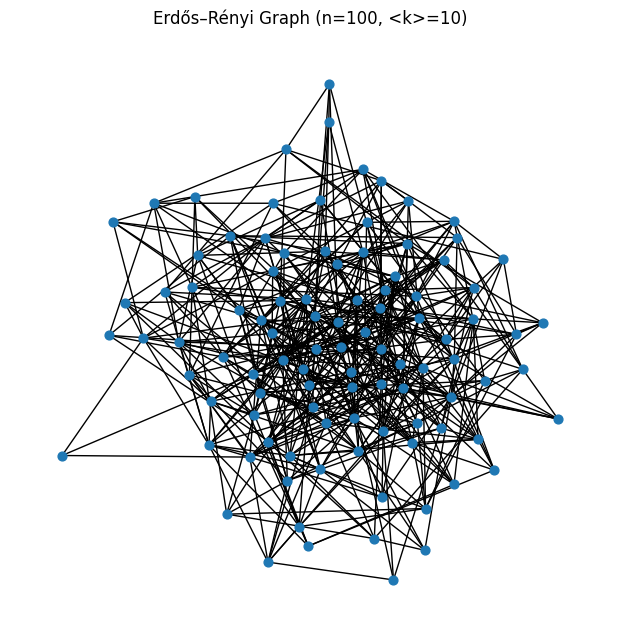

In [6]:
# Parameters
n = 100 #Here is the number of nodes we have in the graph
k_avg = 10 #here it is the average 

# Compute edge probability
p = k_avg / (n - 1) # Calculate the probability of edge creation based on the desired average degree

# Generate Erdős–Rényi graph
G = nx.erdos_renyi_graph(n=n, p=p, seed=42) #using pre defined Function for generating the graph

# Basic checks
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", np.mean([d for _, d in G.degree()])) #Should close to 10, but may vary due to randomness

# Optional: visualize
plt.figure(figsize=(6,6))
nx.draw(G, node_size=40)
plt.title("Erdős–Rényi Graph (n=100, <k>=10)")
plt.show()

## 4.2
#### i. Number of edges removed
The original graph has 482 edges. We remove 20% (96 edges), leaving 386 edges in the training graph.
#### ii. Edge removal strategy
Edges are shuffled randomly and removed sequentially. An edge is removed only if its deletion does not disconnect the graph, ensuring the training network remains connected.
#### iii. Storage of removed edges
Removed edges are stored in a set of canonical pairs (min(u,v), max(u,v)), so that undirected edges (u,v) and (v,u) are treated identically during evaluation.
#### iv. Connectivity issues
Random removals may disconnect the network. To avoid this, an edge is removed only if the graph remains connected after deletion. If the removal fraction were very high, it might be impossible to remove the desired number of edges without breaking connectivity.

In [7]:
# ----------------------------
# 2) Decide how many edges to remove
# ----------------------------
remove_frac = 0.20
m = G.number_of_edges()
m_remove = int(np.floor(remove_frac * m))

print("\nEdge removal plan")
print("  removal fraction:", remove_frac)
print("  edges to remove:", m_remove)

# ----------------------------
# 3) Randomly remove edges, but keep graph connected
#    Strategy: iterate through a randomized edge list and remove an edge only if
#    the graph stays connected after removal.
# ----------------------------
seed = 12345
rng = random.Random(seed)
edges = list(G.edges())
rng.shuffle(edges)

train_graph = G.copy()
removed_edges = []

# Quick guard: if original graph isn't connected, we typically work on its LCC first.
# (ER with <k>=10 is usually connected, but not guaranteed for other params.)
if not nx.is_connected(train_graph):
    lcc_nodes = max(nx.connected_components(train_graph), key=len)
    train_graph = train_graph.subgraph(lcc_nodes).copy()
    print("\nOriginal graph was disconnected; restricted to LCC.")
    print("  LCC nodes:", train_graph.number_of_nodes())
    print("  LCC edges:", train_graph.number_of_edges())

# Now do connectivity-safe removals
for (u, v) in edges:
    if len(removed_edges) >= m_remove:
        break

    # Only consider edges that are actually still present
    if not train_graph.has_edge(u, v):
        continue

    # Tentatively remove
    train_graph.remove_edge(u, v)

    # Check connectivity; if disconnected, undo removal
    if nx.is_connected(train_graph):
        removed_edges.append((u, v))
    else:
        train_graph.add_edge(u, v)

# Report what happened
print("\nAfter removal")
print("  removed edges:", len(removed_edges))
print("  train edges:", train_graph.number_of_edges())
print("  train connected:", nx.is_connected(train_graph))

if len(removed_edges) < m_remove:
    print("\nWARNING: Could not remove the full target number of edges without disconnecting the graph.")
    print("This can happen if the graph has many bridge-like edges at that point.")
    print("Options: remove a smaller fraction, regenerate a denser graph, or allow disconnection and work on LCC.")

# ----------------------------
# 4) Store removed edges in a canonical undirected format for evaluation
# ----------------------------
removed_set = {tuple(sorted((u, v))) for (u, v) in removed_edges}

# Example membership check (order doesn't matter)
example_edge = removed_edges[0] if removed_edges else None
if example_edge:
    u, v = example_edge
    print("\nRemoved-set check example:")
    print("  raw:", (u, v))
    print("  canonical:", tuple(sorted((u, v))))
    print("  in removed_set:", tuple(sorted((u, v))) in removed_set)



Edge removal plan
  removal fraction: 0.2
  edges to remove: 96

After removal
  removed edges: 96
  train edges: 386
  train connected: True

Removed-set check example:
  raw: (0, 10)
  canonical: (0, 10)
  in removed_set: True


## 4.3
#### i Key parameters
The main parameters used here are:
dimensions = 64
Size of the embedding vector for each node.
walk_length = 20
Number of nodes visited in each random walk.
num_walks = 100
Number of random walks started from each node.
workers = 2
Number of CPU threads used in computation.

#### ii dimensions
Higher dimensions can capture more structural information.
But they increase memory use and computation time.
Very high values may also overfit or add noise.
walk_length
Longer walks explore more of the graph.
This may improve embeddings by capturing broader structure.
But longer walks are slower and may add less useful distant information.
num_walks
More walks per node generate more training data.
This often improves embedding quality and stability.
But runtime grows substantially.
workers
More workers make training faster through parallelism.
This affects efficiency, not embedding meaning.
window
Larger windows make nodes co-occurring within wider walk neighborhoods look similar.
Smaller windows focus more on very local structure.

### iii plotting
Yes, the nodes can be visually represented in vector space by projecting the learned embeddings into two dimensions. Since Node2Vec produces a high-dimensional vector for each node, I used PCA to reduce the embeddings to 2D and plotted them in a scatter plot. In this representation, nodes that appear close to each other tend to have similar structural roles or similar network neighborhoods.

Nodes: 100
Edges: 386


Generating walks (CPU: 2): 100%|██████████| 50/50 [00:00<00:00, 98.80it/s] 


Embedding matrix shape: (100, 64)


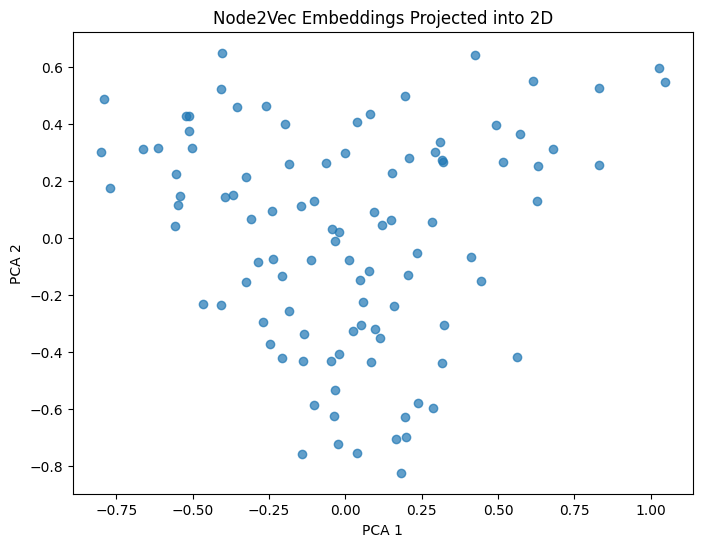

In [10]:
# ----------------------------
# train_graph is assumed to be the graph after edge removal
# ----------------------------
print("Nodes:", train_graph.number_of_nodes())
print("Edges:", train_graph.number_of_edges())

# ----------------------------
# 1) Set Node2Vec parameters
# ----------------------------
dimensions = 64
walk_length = 20
num_walks = 100
workers = 2
window = 10
min_count = 1
batch_words = 4

# Optional Node2Vec bias parameters
p = 1
q = 1

# ----------------------------
# 2) Fit Node2Vec
# ----------------------------
node2vec = Node2Vec(
    train_graph,
    dimensions=dimensions,
    walk_length=walk_length,
    num_walks=num_walks,
    workers=workers,
    p=p,
    q=q,
    seed=42
)

model = node2vec.fit(
    window=window,
    min_count=min_count,
    batch_words=batch_words
)

# ----------------------------
# 3) Extract embeddings
# ----------------------------
nodes = list(train_graph.nodes())
embeddings = np.array([model.wv[str(node)] for node in nodes])

print("Embedding matrix shape:", embeddings.shape)

# ----------------------------
# 4) Optional: PCA for visualization
# ----------------------------
# Reduce to 2 dimensions
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Node2Vec Embeddings Projected into 2D")
plt.show()

## 4.4 
#### i Why using cousin similarity?
Cosine similarity is well suited for embeddings because:
Node2Vec learns vectors where structurally similar nodes have similar directions in embedding space
Cosine similarity captures vector orientation, not magnitude
It is scale-invariant, so vector length does not distort similarity
Thus, if two nodes frequently appear in similar random-walk contexts, their embeddings will be close in direction, producing high cosine similarity.
High similarity therefore suggests a higher probability of a missing link.

the benefits are:
1. Simplicity
Cosine similarity directly measures closeness between embeddings without additional modeling.
2. Computational efficiency
It is very fast to compute and scales well to large graphs.
3. Interpretability
Higher cosine similarity straightforwardly indicates stronger structural similarity.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import itertools

# Get embeddings
nodes = list(train_graph.nodes())
embeddings = {node: model.wv[str(node)] for node in nodes}

# Function to compute cosine similarity
def edge_similarity(u, v):
    vec_u = embeddings[u].reshape(1, -1)
    vec_v = embeddings[v].reshape(1, -1)
    return cosine_similarity(vec_u, vec_v)[0][0]

# Similarity for removed edges (positive examples)
removed_scores = [(u, v, edge_similarity(u, v)) for (u, v) in removed_edges]

# Generate candidate non-edges
non_edges = list(nx.non_edges(train_graph))

# Sample some negatives for evaluation
sample_size = len(removed_edges)
neg_edges = random.sample(non_edges, sample_size)

negative_scores = [(u, v, edge_similarity(u, v)) for (u, v) in neg_edges]

print("Example removed edge score:", removed_scores[0])
print("Example non-edge score:", negative_scores[0])

Example removed edge score: (0, 10, np.float32(0.067858346))
Example non-edge score: (10, 53, np.float32(0.15829188))


## 4.5
Combine the cosine similarity scores from both the positive examples (removed edges) and the negative examples. Then, construct an ROC (Receiver Operating Characteristic) curve and compute the Area Under the ROC Curve (AUC). i. What does the ROC curve represent in the context of link prediction? ii. How do you interpret the AUC value with respect to the quality of your predictions? iii. What does an AUC value of 0.5 versus a value close to 1.0 indicate about your model’s performance?

#### i. What does the ROC curve represent in the context of link prediction?
The ROC curve plots the True Positive Rate (the fraction of actual missing links correctly predicted as links) against the False Positive Rate (the fraction of non-existent edges incorrectly predicted as links) across all possible cosine similarity thresholds. It visualizes the trade-off between correctly guessing hidden links and making false predictions.

#### ii. How do you interpret the AUC value with respect to the quality of your predictions?
The AUC (Area Under the Curve) represents the probability that a randomly chosen true missing edge (a removed edge) has a higher similarity score than a randomly chosen non-edge. The closer the AUC is to 1.0, the better the model is at distinguishing between real links and fake links.

#### iii. What does an AUC value of 0.5 versus a value close to 1.0 indicate about your model’s performance?
An AUC of exactly 0.5 indicates that the model has no discriminative ability, meaning its predictions are no better than random guessing (which is expected on a purely random Erdős-Rényi graph). An AUC close to 1.0 indicates excellent model performance, where the model consistently assigns higher similarity scores to actual missing links than to non-edges.

AUC: 0.4301215277777778


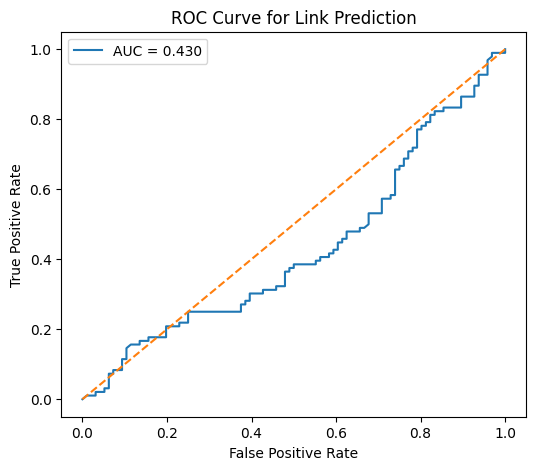

In [13]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Positive scores (removed edges)
pos_scores = [score for (_, _, score) in removed_scores]

# Negative scores (non-existing edges)
neg_scores = [score for (_, _, score) in negative_scores]

# Combine scores
scores = np.array(pos_scores + neg_scores)

# Labels: 1 = true edge (removed), 0 = non-edge
labels = np.array([1]*len(pos_scores) + [0]*len(neg_scores))

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(labels, scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Link Prediction")
plt.legend()
plt.show()



## 4.f 

#### i. How effective was cosine similarity as a scoring method for predicting missing links?
In this specific experiment, cosine similarity was ineffective (AUC ~ 0.43). However, this is largely because the underlying graph is a completely random Erdős-Rényi (ER) graph, which contains no real structure. In graphs that actually possess structure (like homophily or community clusters), cosine similarity on Node2Vec embeddings is usually highly effective at ranking missing links because true missing links tend to be between structurally similar nodes.

#### ii. How might different embedding parameters (dimensions, walk length, etc.) or alternative scoring methods impact the results?
##### Embedding Parameters:
1. Increasing dimensions can capture more complex patterns but requires more data to train correctly without overfitting.
Larger walk_length and window let the model capture global community structures (nodes far apart), while smaller values restrict the embeddings strictly to local neighborhoods.
2. Changing the p (return) and q (in-out) parameters in Node2Vec biases the random walks to behave more like Breadth-First Search (local micro-structure) or Depth-First Search (global macro-structure), depending on what the network dictates.
3. lternative Scoring Methods: Instead of pure cosine similarity, we could use the Hadamard product (element-wise multiplication) or L1/L2 distance between the vectors $u$ and $v$ to create an "edge feature vector." This vector can be fed into a supervised classifier (like Random Forest or XGBoost), which usually performs much better than raw cosine similarity because it can learn non-linear combinations of the latent dimensions.

#### iii. What are the potential limitations of your current methodology, and what improvements would you suggest for future experiments?
- Limitation 1: Testing on a Random Graph. Node2Vec relies on exploiting hidden structural regularities in a graph. An Erdős-Rényi graph has none. Improvement: Test the methodology on a network with actual structure, such as a Watts-Strogatz (small-world) or a real-world dataset (e.g., social networks, citation networks) to truly gauge link prediction capacity.
- Limitation 2: Limited Scoring Mechanism. Cosine similarity treats every dimension equally and only looks at the angle between embeddings. Improvement: Use a supervised machine learning model that takes the transformed Node2Vec embeddings (e.g. Hadamard product of $u$ and $v$) as input features to distinguish true edges from non-edges.
- Limitation 3: Cold Start / Disconnected Graphs. If the removal of 20% of edges heavily fractures the graph or leaves nodes with extremely few connections, Node2Vec struggles to learn meaningful embeddings for those isolated nodes. Improvement: Use a more sophisticated splitting strategy that guarantees the train graph remains a single strongly connected component, and perhaps test against larger graphs, as Node2Vec embeddings improve as the network size scales up.